# Dataset structure

All data will be store in parquet files, we will handle the following columns 

### Sample storage : samples.parquets
| Column name                          | Type      | Explanation                                                  |
| ------------------------------------ | --------- | ------------------------------------------------------------ |
| **sample_id**                        | VARCHAR   | unique identifier of the sample in source dataset          |
| **sample_uuid_id**                   | VARCHAR   | unique identifier of the sample generated                  |
| **sample_type**                      | VARCHAR   | enum from (raw, perturbation_type, adversarial)             |
| **class_id**                         | BIGINT    | 0-n to manipulate classes                                    |
| **transform_id**                     | BIGINT    | corresponding to a transformation parameters, (void if origin) |
| **class_name**                       | VARCHAR   | name of the class (e.g., "buildings", "river", etc.)                |
| **file_name**                        | VARCHAR   | original filename of the image                               |
| **file_path**                        | VARCHAR   | path to the image file                                       |
| **image_bytes**                      | BLOB      | binary data of the image stored directly in the parquet     |


In this notebook, the different table will be generated from source dataset and tools



## Parquets files generations

### Import of needed packages

In [22]:
# Package needed for sample display
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt

# Datascience needed import os
import sys
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset


# Specific import for kcai
import pyarrow.parquet as pq
from kcai_dataset import StratifiedHashSplitter, ParquetDataset, IOConfig, add_uuid_to_parquet

### Notebook configuration

In [23]:
# location of input parquet file
RAW_SPLIT_UUID_PQ_FILE='../tests/data/samples_raw_split_uuid.parquet'

### Exploration of Samples parquest

In [24]:
df = pd.read_parquet(RAW_SPLIT_UUID_PQ_FILE)
print(f"Nombre d'images : {len(df)}")
display(df.head())

Nombre d'images : 2100


,sample_uuid,sample_id,sample_type,class_id,transform_id,class_name,file_name,file_path,image_bytes,image_hash,split
0,ad67a2cd-5038-4624-8c02-61e4f1a98e3d,agricultural_agricultural00,raw,0,0,agricultural,agricultural00.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,85ac47bf0b3e840a,train
1,f6fdeb6c-2ab6-4bb1-9fd7-ab0c83ef24a2,agricultural_agricultural01,raw,0,0,agricultural,agricultural01.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,43dc8b4e25532c06,train
2,bbbb50b4-4e98-4915-9d1b-094f1aea3e3e,agricultural_agricultural02,raw,0,0,agricultural,agricultural02.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,a69e99469e16358e,train
3,1754314d-5829-49e2-a4e5-c46007236f70,agricultural_agricultural03,raw,0,0,agricultural,agricultural03.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,a74704c8879e4b57,train
4,1e1fb4f5-07bb-4b70-a787-bf6393f29ddf,agricultural_agricultural04,raw,0,0,agricultural,agricultural04.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,11f85e41e7dbc1e4,train


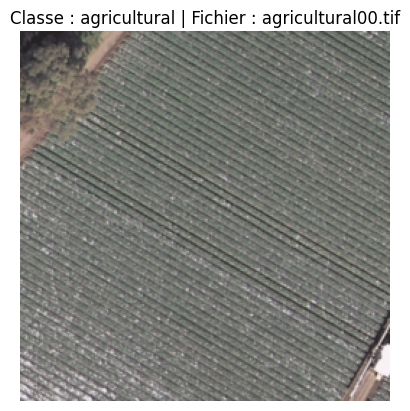

In [25]:
# Package needed for sample display
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt

row = df.iloc[0]
image_bytes = row['image_bytes']
image = Image.open(io.BytesIO(image_bytes))

# Afficher avec matplotlib
plt.imshow(image)
plt.title(f"Classe : {row['class_name']} | Fichier : {row['file_name']}")
plt.axis('off')
plt.show()

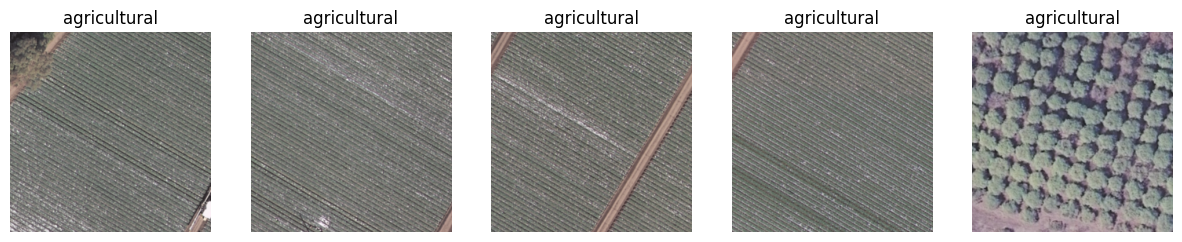

In [26]:
n = 5
plt.figure(figsize=(15, 3))
for i in range(n):
    row = df.iloc[i]
    image = Image.open(io.BytesIO(row['image_bytes']))
    plt.subplot(1, n, i+1)
    plt.imshow(image)
    plt.title(row['class_name'])
    plt.axis('off')
plt.show()

## Split dataset for traceability 

We use kcai to split the parquet associating uuid to sample and provider dataloader for pytorch
The new file will have colonm for split selected, and an uuid for each line

In [27]:
# con
io_cfg = IOConfig(
    id_col="sample_id",
    class_col="class_name",
    image_bytes_col="image_bytes",
    split_col="split"
)

# stratified splitting strategy
splitter = StratifiedHashSplitter(
    by_cols=("class_name",),  # on peut changer les colonnes par lesquelles on veut faire le split, prendre par exemple le sample ID
    ratios=(0.8, 0.1, 0.1)
)


# Import dataset for pytorch

In [28]:
# Image transform

mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

transform = T.Compose([T.Resize((64,64)),
                       T.ToTensor(),
                       T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                       T.ConvertImageDtype(torch.float32)
                      ])

unnormalize = T.Normalize((-mean / std).tolist(), (1.0 / std).tolist())


train_dataset = ParquetDataset( RAW_SPLIT_UUID_PQ_FILE, splitter=None, io_cfg=io_cfg, split="train",transform=transform )
val_dataset = ParquetDataset( RAW_SPLIT_UUID_PQ_FILE, splitter=None,io_cfg=io_cfg, split="val",transform=transform )
test_dataset = ParquetDataset(RAW_SPLIT_UUID_PQ_FILE, splitter=None, io_cfg=io_cfg, split="test",transform=transform)

# Combiner val + test (if needed)
validation_dataset = ConcatDataset([val_dataset, test_dataset])


train_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dl = DataLoader(validation_dataset, batch_size=32, shuffle=True)

dataloaders = {'train': train_dl, 'val': val_dl}
dataset_sizes = {'train': len(train_dataset), 'val': len(validation_dataset)}

In [29]:
print(dataset_sizes)

{'train': 1693, 'val': 407}


In [30]:
# Package needed for sample display
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt

# Datascience needed import os
import sys
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset


from kcai_dataset import StratifiedHashSplitter, ParquetDatasetV2, IOConfig, add_uuid_to_parquet


In [31]:
transforms = {
    "image_bytes" : T.Compose([T.Resize((64,64)),
                       T.ToTensor(),
                       T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                       T.ConvertImageDtype(torch.float32)
                      ])
}
columns = ["class_id", "image_bytes"]
#replace_schema
import pyarrow as pa

schema  = pa.parquet.read_schema(RAW_SPLIT_UUID_PQ_FILE, decryption_properties=None)
metadata = pa.parquet.read_metadata(RAW_SPLIT_UUID_PQ_FILE)
        
from kcai_dataset import update_schema

schema = update_schema(schema, bin_images_colums=['image_bytes'], path_images_columns=[])

train_dataset = ParquetDatasetV2( RAW_SPLIT_UUID_PQ_FILE, columns=columns, schema=schema, transforms=transforms, ret_as_dict=True )

['../tests/data/samples_raw_split_uuid.parquet']
[<pyarrow.dataset.ParquetFileFragment path=../tests/data/samples_raw_split_uuid.parquet>]
sample_uuid: string
sample_id: string
sample_type: string
class_id: int64
transform_id: int64
class_name: string
file_name: string
file_path: string
image_bytes: binary
  -- field metadata --
  kcai_read: 'binary_img'
image_hash: string
split: string


In [32]:
train_dl = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [33]:
dataloaders = {'train': train_dl}
dataset_sizes = {'train': len(train_dataset)}

In [34]:
print(dataset_sizes)

{'train': 2100}


In [35]:
for batch in train_dl:
    print(batch)
    break

__getitem__ 1087
10
col meta image_bytes {b'kcai_read': b'binary_img'}
col read type image_bytes binary_img
image/tiff
apply transform on col image_bytes
datas <class 'list'> 2
datas <class 'int'> 2
datas <class 'torch.Tensor'> 2
__getitem__ 93
0
col meta image_bytes {b'kcai_read': b'binary_img'}
col read type image_bytes binary_img
image/tiff
apply transform on col image_bytes
datas <class 'list'> 2
datas <class 'int'> 2
datas <class 'torch.Tensor'> 2
__getitem__ 1716
17
col meta image_bytes {b'kcai_read': b'binary_img'}
col read type image_bytes binary_img
image/tiff
apply transform on col image_bytes
datas <class 'list'> 2
datas <class 'int'> 2
datas <class 'torch.Tensor'> 2
__getitem__ 1162
11
col meta image_bytes {b'kcai_read': b'binary_img'}
col read type image_bytes binary_img
image/tiff
apply transform on col image_bytes
datas <class 'list'> 2
datas <class 'int'> 2
datas <class 'torch.Tensor'> 2
{'class_id': tensor([10,  0, 17, 11]), 'image_bytes': tensor([[[[-0.5373, -0.5059, 